In [65]:
import numpy as np
import matplotlib.pyplot as plt
import taichi as ti

ti.init(arch=ti.cpu)

[Taichi] Starting on arch=x64


In [66]:

a = 1.0          # spring rest length
m = 1.0          # node mass

k = 100.0          # passive spring stiffness
ko = 100.0        # odd stiffness

# Saturation for odd force
fmax = 0.1*ko * a

# Bond-wise viscous damping coefficient.
# eta = 0 means no damping.
damping_ratio = 0.05
eta = 2.0 * np.sqrt(k * m) * damping_ratio
# Optional global velocity damping.
# Keep it zero for the cleanest internal-force test.
mu = 0.0
amp = 1e-2       # initial displacement of the middle node
omega = np.sqrt(k / m)
periodicity = 2.0 * np.pi / omega
t_step = 50
dt = periodicity / t_step


total_step = 4000
record_every = 10

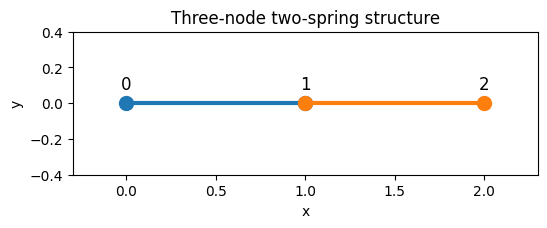

In [67]:
N_nodes = 3
N_bonds = 2

nodes_np = np.array([
    [0.0, 0.0],
    [a , 0.0],
    [2.0 * a, 0.0],
], dtype=np.float32)
vel_np = np.zeros((N_nodes, 2), dtype=np.float32)

bonds_np = np.array([
    [0, 1],
    [1, 2],
], dtype=np.int32)

rest_length_np = np.array([
    a,
    a,
], dtype=np.float32)

fig, ax = plt.subplots(figsize=(6, 2))

# draw bonds
for i, j in bonds_np:
    ax.plot(
        [nodes_np[i, 0], nodes_np[j, 0]],
        [nodes_np[i, 1], nodes_np[j, 1]],
        "-o",
        linewidth=3,
        markersize=10,
    )

# node labels
for i in range(N_nodes):
    ax.text(
        nodes_np[i, 0],
        nodes_np[i, 1] + 0.08,
        f"{i}",
        ha="center",
        fontsize=12,
    )

ax.set_aspect("equal")
ax.set_xlim(-0.3 * a, 2.3 * a)
ax.set_ylim(-0.4 * a, 0.4 * a)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Three-node two-spring structure")
ax.grid(False)

plt.show()

In [68]:

pos = ti.Vector.field(2, dtype=ti.f32, shape=N_nodes)
vel = ti.Vector.field(2, dtype=ti.f32, shape=N_nodes)
force = ti.Vector.field(2, dtype=ti.f32, shape=N_nodes)

bonds = ti.Vector.field(2, dtype=ti.i32, shape=N_bonds)
rest_length = ti.field(dtype=ti.f32, shape=N_bonds)

extension = ti.field(dtype=ti.f32, shape=N_bonds)
tension = ti.field(dtype=ti.f32, shape=N_bonds)

# records
pos_record = ti.Vector.field(2, dtype=ti.f32, shape=(total_step, N_nodes))
vel_record = ti.Vector.field(2, dtype=ti.f32, shape=(total_step, N_nodes))
extension_record = ti.field(dtype=ti.f32, shape=(total_step, N_bonds))
tension_record = ti.field(dtype=ti.f32, shape=(total_step, N_bonds))

pos.from_numpy(nodes_np)
vel.from_numpy(vel_np)
bonds.from_numpy(bonds_np)
rest_length.from_numpy(rest_length_np)

def pertubation(amp_value=amp):
    global nodes_np, vel_np

    nodes_np = np.array([
        [0.0, 0.0],
        [a + amp_value, 0.0],
        [2.0 * a, 0.0],
    ], dtype=np.float32)

    vel_np = np.zeros((N_nodes, 2), dtype=np.float32)

    # if Taichi fields already exist, reload them
    pos.from_numpy(nodes_np)
    vel.from_numpy(vel_np)

@ti.func
def clamp(x, xmin, xmax):
    return ti.min(ti.max(x, xmin), xmax)


@ti.kernel
def zero_force():
    for i in range(N_nodes):
        force[i] = ti.Vector([0.0, 0.0])


@ti.kernel
def nodal_f_passive():
    for b in range(N_bonds):
        i = bonds[b][0]
        j = bonds[b][1]

        rij = pos[j] - pos[i]
        lij = rij.norm()

        if lij > 1e-8:
            eij = rij / lij

            dl = lij - rest_length[b]
            extension[b] = dl

            vij = vel[j] - vel[i]
            dl_dt = vij.dot(eij)

            T = k * dl + eta * dl_dt
            tension[b] = T

            force[i] += T * eij
            force[j] -= T * eij


@ti.func
def apply_bond_tension(b: ti.i32, T: ti.f32):
    i = bonds[b][0]
    j = bonds[b][1]

    r = pos[j] - pos[i]
    e = r / r.norm()

    force[i] += T * e
    force[j] -= T * e


@ti.kernel
def nodal_f_active():
    d1 = extension[0]
    d2 = extension[1]

    T1 = clamp(ko * d2, -fmax, fmax)
    T2 = clamp(-ko * d1, -fmax, fmax)

    tension[0] += T1
    tension[1] += T2

    apply_bond_tension(0, T1)
    apply_bond_tension(1, T2)

@ti.kernel
def update():
    for i in range(N_nodes):
        force[i] += -mu * vel[i]

        vel[i] += dt * force[i] / m
        pos[i] += dt * vel[i]


@ti.kernel
def data_record(frame: ti.i32):
    for i in range(N_nodes):
        pos_record[frame, i] = pos[i]
        vel_record[frame, i] = vel[i]

    for b in range(N_bonds):
        extension_record[frame, b] = extension[b]
        tension_record[frame, b] = tension[b]


In [69]:
pertubation(amp_value=amp)

zero_force()
nodal_f_passive()
nodal_f_active()

print("extension =", extension.to_numpy())
print("tension =", tension.to_numpy())
print("force =")
print(force.to_numpy())

extension = [ 0.00999999 -0.00999999]
tension = [ 0.        -1.9999981]
force =
[[ 0.         0.       ]
 [-1.9999981  0.       ]
 [ 1.9999981  0.       ]]


In [70]:
pertubation(amp_value=amp*10)

zero_force()
nodal_f_passive()
nodal_f_active()
data_record(0)

from tqdm import tqdm

for ii in tqdm(range(total_step - 1), desc="Simulating"):
    zero_force()
    nodal_f_passive()
    nodal_f_active()
    update()

    data_record(ii + 1)

Simulating: 100%|██████████| 3999/3999 [00:03<00:00, 1278.13it/s]


In [71]:
# ============================================================
# Cell 6: GGUI visualization for three-node two-spring model
# ============================================================

# bond indices for scene.lines
bonds_ti = ti.field(dtype=ti.i32, shape=N_bonds * 2)
bonds_ti.from_numpy(bonds_np.flatten().astype(np.int32))

# 3D rendering position field
pos_render = ti.Vector.field(3, dtype=ti.f32, shape=N_nodes)


def set_render_pos(frame_2d):
    frame_3d = np.zeros((N_nodes, 3), dtype=np.float32)
    frame_3d[:, 0] = frame_2d[:, 0]   # x
    frame_3d[:, 1] = frame_2d[:, 1]   # y
    frame_3d[:, 2] = 0.0              # z = 0
    pos_render.from_numpy(frame_3d)


def video(plt_step=1, close=1, save=0):
    pos_np = pos_record.to_numpy()[::plt_step]
    N_step = len(pos_np)

    window = ti.ui.Window(
        f"three-node two-spring odd model: ko={ko}",
        (700, 450),
        vsync=True,
        fps_limit=60,
        pos=(150, 150),
    )

    canvas = window.get_canvas()
    canvas.set_background_color((1, 1, 1))

    scene = window.get_scene()
    camera = ti.ui.Camera()
    gui = window.get_gui()

    # camera setup
    camera.position(1.0, 1.0, 4.0)
    camera.lookat(1.0, 0.0, 0.0)
    camera.up(0.0, 1.0, 0.0)

    pause = False
    step = 0

    while window.running:
        camera.track_user_inputs(window, movement_speed=0.05, hold_key=ti.ui.RMB)
        scene.set_camera(camera)

        scene.ambient_light((0.6, 0.6, 0.6))
        scene.point_light(pos=(2.0, 2.0, 4.0), color=(1, 1, 1))

        for e in window.get_events(ti.ui.PRESS):
            if e.key == ti.ui.ESCAPE:
                window.running = False
            elif e.key == ti.ui.SPACE:
                pause = not pause

        if window.is_pressed("r"):
            step = 0
        if window.is_pressed("z"):
            step += 10
        if window.is_pressed("x"):
            step -= 10

        step = max(0, min(step, N_step - 1))

        with gui.sub_window("Simulation", 0.00, 0.88, 0.45, 0.12) as w:
            w.text(f"frame: {step}/{N_step - 1}")
            w.text(f"physical step: {step * plt_step * t_step}")

        # initial configuration: gray
        set_render_pos(pos_np[0])
        scene.lines(
            vertices=pos_render,
            indices=bonds_ti,
            color=(0.55, 0.55, 0.55),
            width=2.0,
        )

        # current configuration: black bonds
        set_render_pos(pos_np[step])
        scene.lines(
            vertices=pos_render,
            indices=bonds_ti,
            color=(0.0, 0.0, 0.0),
            width=8.0,
        )

        # current nodes
        scene.particles(
            pos_render,
            radius=0.045 * a,
            color=(0.1, 0.2, 0.9),
        )

        # trajectory tails
        tail_num = 10
        tail_gap = 2

        for i in range(tail_num):
            step_i = step - i * tail_gap
            if step_i >= 0:
                set_render_pos(pos_np[step_i])
                scene.particles(
                    pos_render,
                    radius=0.035 * a * (1.0 - 0.05 * i),
                    color=(0.2 + 0.05 * i, 0.2 + 0.05 * i, 1.0),
                )

        canvas.scene(scene)
        window.show()

        if not pause:
            step += 1

        if step >= N_step:
            if close == 1:
                window.running = False
            else:
                step = N_step - 1
                pause = True
video(plt_step=1, close=0)

Warning! Odd drawing count will be cut to neast even number
Warning! Odd drawing count will be cut to neast even number
Warning! Odd drawing count will be cut to neast even number
Warning! Odd drawing count will be cut to neast even number
Warning! Odd drawing count will be cut to neast even number
Warning! Odd drawing count will be cut to neast even number
Warning! Odd drawing count will be cut to neast even number
Warning! Odd drawing count will be cut to neast even number
Warning! Odd drawing count will be cut to neast even number
Warning! Odd drawing count will be cut to neast even number
Warning! Odd drawing count will be cut to neast even number
Warning! Odd drawing count will be cut to neast even number
Warning! Odd drawing count will be cut to neast even number
Warning! Odd drawing count will be cut to neast even number
Warning! Odd drawing count will be cut to neast even number
Warning! Odd drawing count will be cut to neast even number
Warning! Odd drawing count will be cut t

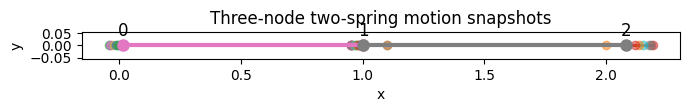

In [ ]:
# Convert records to numpy
pos_np = pos_record.to_numpy()          # shape: (total_step, N_nodes, 2)
vel_np_record = vel_record.to_numpy()
ext_np = extension_record.to_numpy()    # shape: (total_step, N_bonds)
ten_np = tension_record.to_numpy()

time = np.arange(total_step) * dt * t_step
# ------------------------------------------------------------
# Structure snapshots
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 3))

snapshot_ids = np.linspace(0, total_step - 1, 8, dtype=int)

for frame in snapshot_ids:
    nodes = pos_np[frame]

    # draw bonds
    for i, j in bonds_np:
        ax.plot(
            [nodes[i, 0], nodes[j, 0]],
            [nodes[i, 1], nodes[j, 1]],
            "-o",
            linewidth=2,
            markersize=6,
            alpha=0.5,
        )

# final frame emphasized
nodes = pos_np[-1]
for i, j in bonds_np:
    ax.plot(
        [nodes[i, 0], nodes[j, 0]],
        [nodes[i, 1], nodes[j, 1]],
        "-o",
        linewidth=3,
        markersize=8,
    )

for i in range(N_nodes):
    ax.text(
        nodes[i, 0],
        nodes[i, 1] + 0.04,
        f"{i}",
        ha="center",
        fontsize=12,
    )

ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Three-node two-spring motion snapshots")
ax.grid(False)

plt.tight_layout()
plt.show()

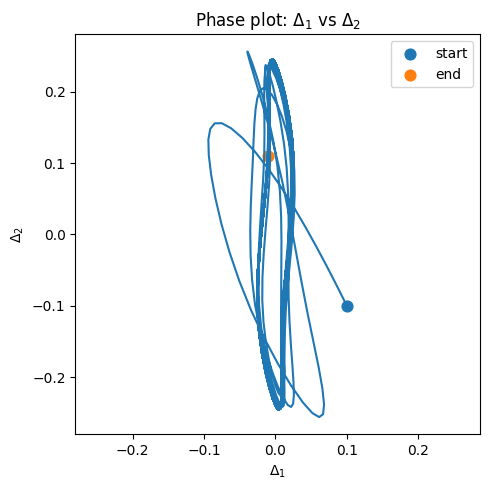

In [62]:
# ============================================================
# Cell: Phase plot of Delta_1 and Delta_2
# ============================================================

ext_np = extension_record.to_numpy()   # shape: (total_step, N_bonds)

Delta1 = ext_np[:, 0]
Delta2 = ext_np[:, 1]

plt.figure(figsize=(5, 5))
plt.plot(Delta1, Delta2, linewidth=1.5)

plt.scatter(Delta1[0], Delta2[0], s=60, label="start")
plt.scatter(Delta1[-1], Delta2[-1], s=60, label="end")

plt.xlabel(r"$\Delta_1$")
plt.ylabel(r"$\Delta_2$")
plt.title(r"Phase plot: $\Delta_1$ vs $\Delta_2$")
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.show()

## Questions for Case 1

1. Why is an initial perturbation needed for this system to move?

2. What are $\Delta_1$ and $\Delta_2$, and how are they computed from the node positions?

3. What is the difference between passive spring force, viscous damping, and odd active force?

4. Why is the odd coupling called non-reciprocal?

5. Under what conditions does the amplitude decay, grow, or become limited by saturation?